#📌 Extracción

In [4]:
import pandas as pd

# URL del archivo JSON en formato Raw
url_json = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    # Cargamos los datos directamente
    df_telecom = pd.read_json(url_json)
    print("✅ DataFrame creado exitosamente.")
    print(f"Filas: {df_telecom.shape[0]} | Columnas: {df_telecom.shape[1]}")
except Exception as e:
    print(f"Hubo un error al cargar los datos: {e}")

# Visualización de las primeras 5 filas
df_telecom.head()

✅ DataFrame creado exitosamente.
Filas: 7267 | Columnas: 6


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [5]:
#Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.
# Resumen técnico de las columnas
# Resumen técnico de las columnas
df_telecom.info()

# Conteo de valores nulos por columna
print("\nValores faltantes:")
print(df_telecom.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

Valores faltantes:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [6]:
#Análisis de la variable objetivo (Churn)
#Es fundamental saber cuántos clientes se han ido realmente en nuestra muestra:
# Distribución de la evasión
print(df_telecom['Churn'].value_counts(normalize=True) * 100)

Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


#🔧 Transformación

In [8]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()

# Aplanamos la estructura anidada del JSON para que coincida con el diccionario
df = pd.json_normalize(data)

# Verificamos los tipos de datos generados
print("--- Información del DataFrame ---")
df.info()

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechS

In [9]:
# Corrección de tipos de datos para análisis financiero
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0) # Manejo de valores vacíos

In [10]:
# Corrección de tipos de datos para análisis financiero
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0) # Manejo de valores vacíos

In [11]:
# Estadísticas para variables numéricas clave
variables_clave = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
print("\n--- Resumen Estadístico ---")
print(df[variables_clave].describe())

# Verificación de balanceo en la evasión (Churn)
print("\n--- Proporción de Evasión (Churn) ---")
print(df['Churn'].value_counts(normalize=True) * 100)


--- Resumen Estadístico ---
       customer.tenure  account.Charges.Monthly  account.Charges.Total
count      7267.000000              7267.000000            7267.000000
mean         32.346498                64.720098            2277.182035
std          24.571773                30.129572            2268.648587
min           0.000000                18.250000               0.000000
25%           9.000000                35.425000             396.200000
50%          29.000000                70.300000            1389.200000
75%          55.000000                89.875000            3778.525000
max          72.000000               118.750000            8684.800000

--- Proporción de Evasión (Churn) ---
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [13]:
#Carga y Normalización (Aplanar los datos)
#Usaremos json_normalize para que cada nivel del JSON se convierta en una columna independiente.
import pandas as pd
import json
# Cargamos el archivo JSON
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

# "Aplanamos" la estructura anidada
df = pd.json_normalize(data)

# Verificamos cómo quedaron los nombres de las columnas
print("Primeras 5 columnas tras normalizar:")
print(df.columns[:5])

Primeras 5 columnas tras normalizar:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner'],
      dtype='object')


In [14]:
#validacion con el diccionario
# 1. Convertir 'account.Charges.Total' a numérico (importante para cálculos)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# 2. Manejar valores nulos (surgen si hay espacios vacíos en el JSON)
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# 3. Verificamos los tipos finales
print(df[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].dtypes)

customer.tenure              int64
account.Charges.Monthly    float64
account.Charges.Total      float64
dtype: object


In [15]:
# ¿Qué porcentaje de clientes hemos perdido?
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [16]:
#✅ Explorar las columnas del dataset y verificar sus tipos de datos.
# Tras normalizar con pd.json_normalize(data)
print(df.info())
#✅ Consultar el diccionario para comprender mejor el significado de las variables.
#✅ Identificar las columnas más relevantes para el análisis de evasión.
# Corrección de seguridad
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce').fillna(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
#comprobacion de inconsistencias



In [17]:
#deteccion de valores ausentes(NaN)
# Conteo de valores nulos por columna

print("Valores ausentes por columna:")
print(df.isnull().sum())

# Visualización de filas con nulos (si existen)
nulos = df[df.isnull().any(axis=1)]

Valores ausentes por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [18]:
# Identificacion de duplicados
# Verificar si hay filas idénticas
duplicados = df.duplicated().sum()
print(f"Registros duplicados totales: {duplicados}")

# Verificar si hay IDs de cliente repetidos (no debería haber ninguno)
id_duplicados = df['customerID'].duplicated().sum()
print(f"IDs de cliente duplicados: {id_duplicados}")

# Si existen, eliminarlos:
# df = df.drop_duplicates(subset='customerID', keep='first')

Registros duplicados totales: 0
IDs de cliente duplicados: 0


In [19]:
#Errores de formato
# Forzar la conversión a numérico y marcar errores como NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificar cuántos valores no eran numéricos (ahora son NaN)
print(f"Valores no numéricos encontrados en TotalCharges: {df['account.Charges.Total'].isnull().sum()}")

# Imputar: Si tenure es 0, el gasto total debe ser 0
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

Valores no numéricos encontrados en TotalCharges: 0


In [20]:
#Inconsistencias de categoria
# Revisar valores únicos de columnas categóricas clave
categorias_a_revisar = ['account.Contract', 'internet.InternetService', 'account.PaymentMethod']

for col in categorias_a_revisar:
    print(f"Valores únicos en {col}: {df[col].unique()}")

Valores únicos en account.Contract: ['One year' 'Month-to-month' 'Two year']
Valores únicos en internet.InternetService: ['DSL' 'Fiber optic' 'No']
Valores únicos en account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [21]:
#validacion de rangos lógicos
# Resumen estadístico para detectar valores atípicos (outliers)
print(df[['customer.tenure', 'account.Charges.Monthly']].describe())

# ¿Hay clientes con antigüedad negativa?
print(f"Tenure negativo: {(df['customer.tenure'] < 0).sum()}")

       customer.tenure  account.Charges.Monthly
count      7267.000000              7267.000000
mean         32.346498                64.720098
std          24.571773                30.129572
min           0.000000                18.250000
25%           9.000000                35.425000
50%          29.000000                70.300000
75%          55.000000                89.875000
max          72.000000               118.750000
Tenure negativo: 0


In [22]:
#Manejo de inconsistencias
#duplicados eliminados
# Eliminación de duplicados exactos en todo el DataFrame
antes = df.shape[0]
df = df.drop_duplicates()
despues = df.shape[0]

# Eliminación por ID de cliente (por si hay IDs repetidos con datos distintos)
df = df.drop_duplicates(subset='customerID', keep='first')

print(f"Registros eliminados: {antes - despues}")

Registros eliminados: 0


In [29]:
#Imputación especifica por variable
# Convertimos a numérico primero (esto crea NaNs donde había espacios)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Imputamos con 0 los casos donde el cliente es nuevo (tenure == 0)
df.loc[df['customer.tenure'] == 0, 'account.Charges.Total'] = 0

In [28]:
#imputacion estadistica
mediana_mensual = df['account.Charges.Monthly'].median()
df['account.Charges.Monthly'] = df['account.Charges.Monthly'].fillna(mediana_mensual)

In [27]:
#imputacion por desconocido
columnas_cat = ['internet.InternetService', 'account.PaymentMethod']
for col in columnas_cat:
    df[col] = df[col].fillna('No disponible')

In [30]:
import pandas as pd
import numpy as np

# 1. ELIMINACIÓN DE DUPLICADOS
# Primero quitamos filas idénticas
df = df.drop_duplicates()

# Luego nos aseguramos de que no haya IDs de cliente repetidos (integridad referencial)
df = df.drop_duplicates(subset='customerID', keep='first')


# 2. IMPUTACIÓN DE VALORES FALTANTES (REPARACIÓN)

# A. Reparación de 'account.Charges.Total'
# Convertimos a numérico: los espacios vacíos se vuelven NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Lógica: Si el cliente es nuevo (tenure=0), su gasto total DEBE ser 0.
df.loc[df['customer.tenure'] == 0, 'account.Charges.Total'] = 0

# B. Imputación Estadística para Cargos Mensuales
# Si faltara algún monto mensual, usamos la mediana para no afectar la distribución
mediana_mensual = df['account.Charges.Monthly'].median()
df['account.Charges.Monthly'] = df['account.Charges.Monthly'].fillna(mediana_mensual)

# C. Imputación de Variables Categóricas
# Para servicios o métodos de pago faltantes, creamos la etiqueta 'Sin Información'
columnas_servicios = [
    'internet.InternetService', 'internet.OnlineSecurity',
    'internet.TechSupport', 'account.PaymentMethod'
]

for col in columnas_servicios:
    if col in df.columns:
        df[col] = df[col].fillna('Sin Información')

print("✅ Limpieza e imputación completadas con éxito.")
print(f"Total de registros finales: {df.shape[0]}")

✅ Limpieza e imputación completadas con éxito.
Total de registros finales: 7267


In [33]:
#Creacion de la columna cuentas_diaras
# Definimos el factor de conversión (días del mes)
DIAS_MES = 30

# Creamos la nueva columna mediante una operación aritmética simple
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / DIAS_MES

# Redondeamos a 2 decimales para que sea legible (formato moneda)
df['Cuentas_Diarias'] = df['Cuentas_Diarias'].round(2)

print("✅ Columna 'Cuentas_Diarias' creada exitosamente.")

✅ Columna 'Cuentas_Diarias' creada exitosamente.


In [34]:
# Verificamos las primeras filas para confirmar el cálculo
print(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head())

# Resumen estadístico del gasto diario
print("\nResumen del gasto diario:")
print(df['Cuentas_Diarias'].describe())

   account.Charges.Monthly  Cuentas_Diarias
0                     65.6             2.19
1                     59.9             2.00
2                     73.9             2.46
3                     98.0             3.27
4                     83.9             2.80

Resumen del gasto diario:
count    7267.000000
mean        2.157292
std         1.004407
min         0.610000
25%         1.180000
50%         2.340000
75%         2.995000
max         3.960000
Name: Cuentas_Diarias, dtype: float64


In [35]:
#mapeo binario (encoding)
# Mapeo de valores textuales a binarios
mapeo = {'Yes': 1, 'No': 0}

# Aplicamos a la variable objetivo y otras relevantes
columnas_binarias = ['Churn', 'phone.PhoneService', 'account.PaperlessBilling']

for col in columnas_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapeo)

# Para SeniorCitizen ya suele venir como 0 y 1, pero aseguramos:
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].astype(int)

In [36]:
#traduccion y renombrado de columnas
# Diccionario de traducción
nuevos_nombres = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasión',
    'customer.gender': 'Género',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.tenure': 'Meses_Antigüedad',
    'account.Contract': 'Tipo_Contrato',
    'account.Charges.Monthly': 'Cargos_Mensuales',
    'account.Charges.Total': 'Cargos_Totales',
    'account.PaymentMethod': 'Metodo_Pago',
    'Cuentas_Diarias': 'Costo_Diario'
}

df_final = df.rename(columns=nuevos_nombres)

In [37]:
#estandarizacion de categorias
# Traducir los tipos de contrato
contratos = {
    'Month-to-month': 'Mensual',
    'One year': 'Anual',
    'Two year': 'Bianual'
}
df_final['Tipo_Contrato'] = df_final['Tipo_Contrato'].replace(contratos)

#📊 Carga y análisis

In [38]:
#Resumen de variables numericas

# Seleccionamos las columnas numéricas clave ya traducidas
columnas_numericas = ['Meses_Antigüedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Costo_Diario']

# Generamos el resumen estadístico
resumen_est = df_final[columnas_numericas].describe().transpose()

# Añadimos la mediana (que describe mejor si hay valores extremos)
resumen_est['median'] = df_final[columnas_numericas].median()

# Reorganizamos para mayor claridad
resumen_est = resumen_est[['mean', 'median', 'std', 'min', 'max']]
resumen_est.columns = ['Media', 'Mediana', 'Desv. Estándar', 'Mínimo', 'Máximo']

print("--- Perfil Estadístico de los Clientes ---")
print(resumen_est.round(2))

--- Perfil Estadístico de los Clientes ---
                    Media  Mediana  Desv. Estándar  Mínimo   Máximo
Meses_Antigüedad    32.35    29.00           24.57    0.00    72.00
Cargos_Mensuales    64.72    70.30           30.13   18.25   118.75
Cargos_Totales    2277.18  1389.20         2268.65    0.00  8684.80
Costo_Diario         2.16     2.34            1.00    0.61     3.96


Interpretación de las Métricas
Al observar los resultados, podrás extraer estos primeros insights de negocio:

Meses_Antigüedad: Si la Media es mucho mayor que la Mediana, significa que tienes muchos clientes nuevos que podrían estar en riesgo de fuga.

Cargos_Mensuales: Una Desviación Estándar alta indica que tu cartera de clientes es muy diversa (tienes desde planes muy básicos hasta servicios premium).

Costo_Diario: Esta métrica te dirá cuánto desembolsa el cliente cada 24 horas. Es la métrica ideal para comparar con la competencia.

In [39]:
#analisis de segmentacion (evasion vs no evasion)

# Comparativa de promedios según la Evasión (0 = Se queda, 1 = Se va)
comparativa_churn = df_final.groupby('Evasión')[columnas_numericas].mean()

print("\n--- Promedio de Variables: Leales vs. Evasores ---")
print(comparativa_churn.round(2))


--- Promedio de Variables: Leales vs. Evasores ---
         Meses_Antigüedad  Cargos_Mensuales  Cargos_Totales  Costo_Diario
Evasión                                                                  
0.0                 37.57             61.27         2549.91          2.04
1.0                 17.98             74.44         1531.80          2.48


Análisis de Variables Categóricas (Frecuencias)
No todo es números; saber qué servicios son los más populares también es parte del análisis descriptivo.

In [40]:
# ¿Cuál es el contrato más común?
print("\nDistribución por Tipo de Contrato:")
print(df_final['Tipo_Contrato'].value_counts(normalize=True) * 100)

# ¿Qué método de pago predomina?
print("\nDistribución por Método de Pago:")
print(df_final['Metodo_Pago'].value_counts(normalize=True) * 100)


Distribución por Tipo de Contrato:
Tipo_Contrato
Mensual    55.112151
Bianual    23.985138
Anual      20.902711
Name: proportion, dtype: float64

Distribución por Método de Pago:
Metodo_Pago
Electronic check             33.645246
Mailed check                 22.911793
Bank transfer (automatic)    21.865969
Credit card (automatic)      21.576992
Name: proportion, dtype: float64


visualizacion de la proporción de los datos

/tmp/ipykernel_167/1177658415.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Evasión', ax=ax[0], palette='viridis')


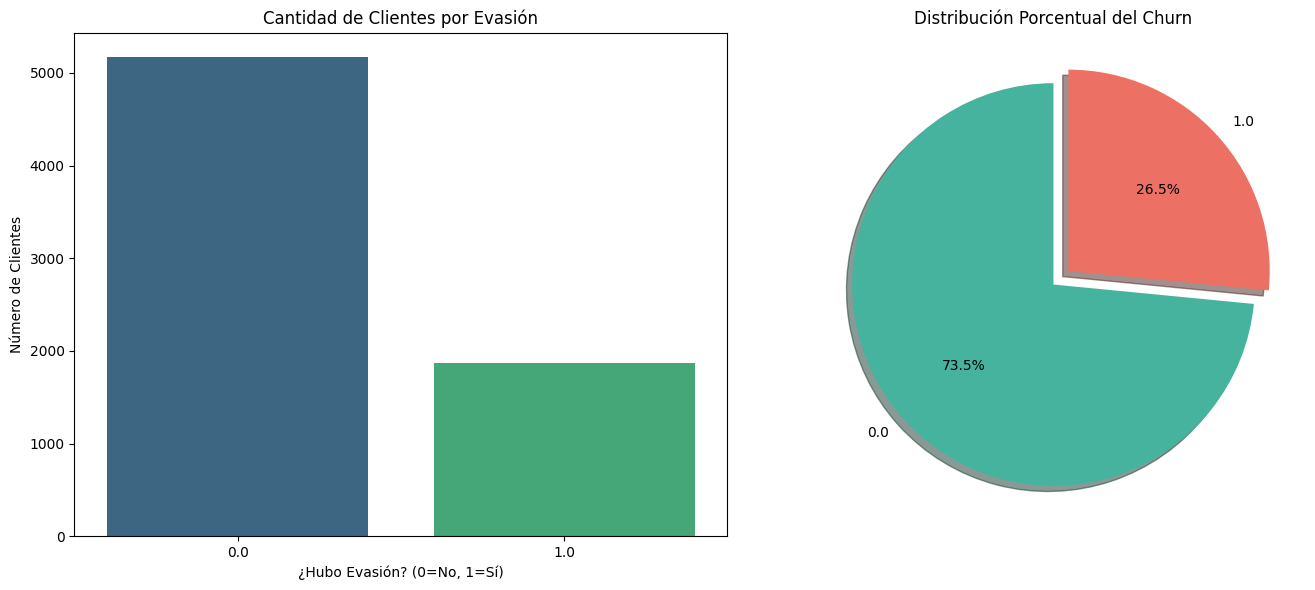

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el área de dibujo con dos subgráficos
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Conteo (Frecuencia Absoluta)
sns.countplot(data=df_final, x='Evasión', ax=ax[0], palette='viridis')
ax[0].set_title('Cantidad de Clientes por Evasión')
ax[0].set_xlabel('¿Hubo Evasión? (0=No, 1=Sí)')
ax[0].set_ylabel('Número de Clientes')

# Gráfico 2: Porcentaje (Frecuencia Relativa)
df_final['Evasión'].value_counts().plot.pie(
    autopct='%1.1f%%',
    explode=[0, 0.1],
    ax=ax[1],
    shadow=True,
    startangle=90,
    colors=['#45B39D', '#EC7063']
)
ax[1].set_title('Distribución Porcentual del Churn')
ax[1].set_ylabel('') # Eliminamos la etiqueta vertical

plt.tight_layout()
plt.show()

Interpretación de los Resultados
Al observar estos gráficos, podemos extraer conclusiones inmediatas para el equipo de Data Science:

Tasa de Evasión: Si el gráfico muestra que aproximadamente el 26.5% de los clientes se han ido (valor típico en este dataset), estamos ante una tasa de deserción considerable que justifica el proyecto.

Desbalanceo de Clases: Observarás que hay muchos más clientes que se quedan (Clase 0) que los que se van (Clase 1).

Nota técnica: Esto es normal en problemas de Churn. Si el desbalance es muy fuerte (ej. 90% vs 10%), el equipo de Machine Learning tendrá que usar técnicas como SMOTE o submuestreo para que el modelo no aprenda solo a decir "No" a todo.

Profundizando en el "Por Qué"
Para que este análisis sea estratégico, no basta con saber cuántos se van, sino quiénes son. Una técnica rápida es ver la evasión cruzada con otra variable crítica del diccionario, como el Adulto Mayor.

/tmp/ipykernel_167/1549426976.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Adulto_Mayor', y='Evasión', palette='coolwarm')


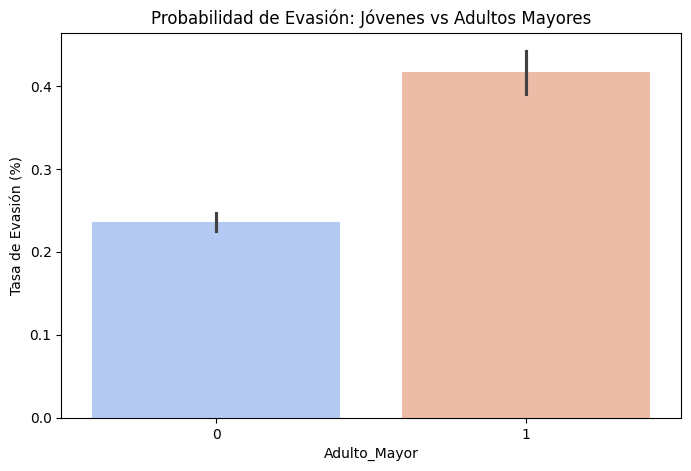

In [42]:
# ¿Los adultos mayores se van más que los jóvenes?
plt.figure(figsize=(8, 5))
sns.barplot(data=df_final, x='Adulto_Mayor', y='Evasión', palette='coolwarm')
plt.title('Probabilidad de Evasión: Jóvenes vs Adultos Mayores')
plt.ylabel('Tasa de Evasión (%)')
plt.show()

Visualizacion de evasion por variables categoricas

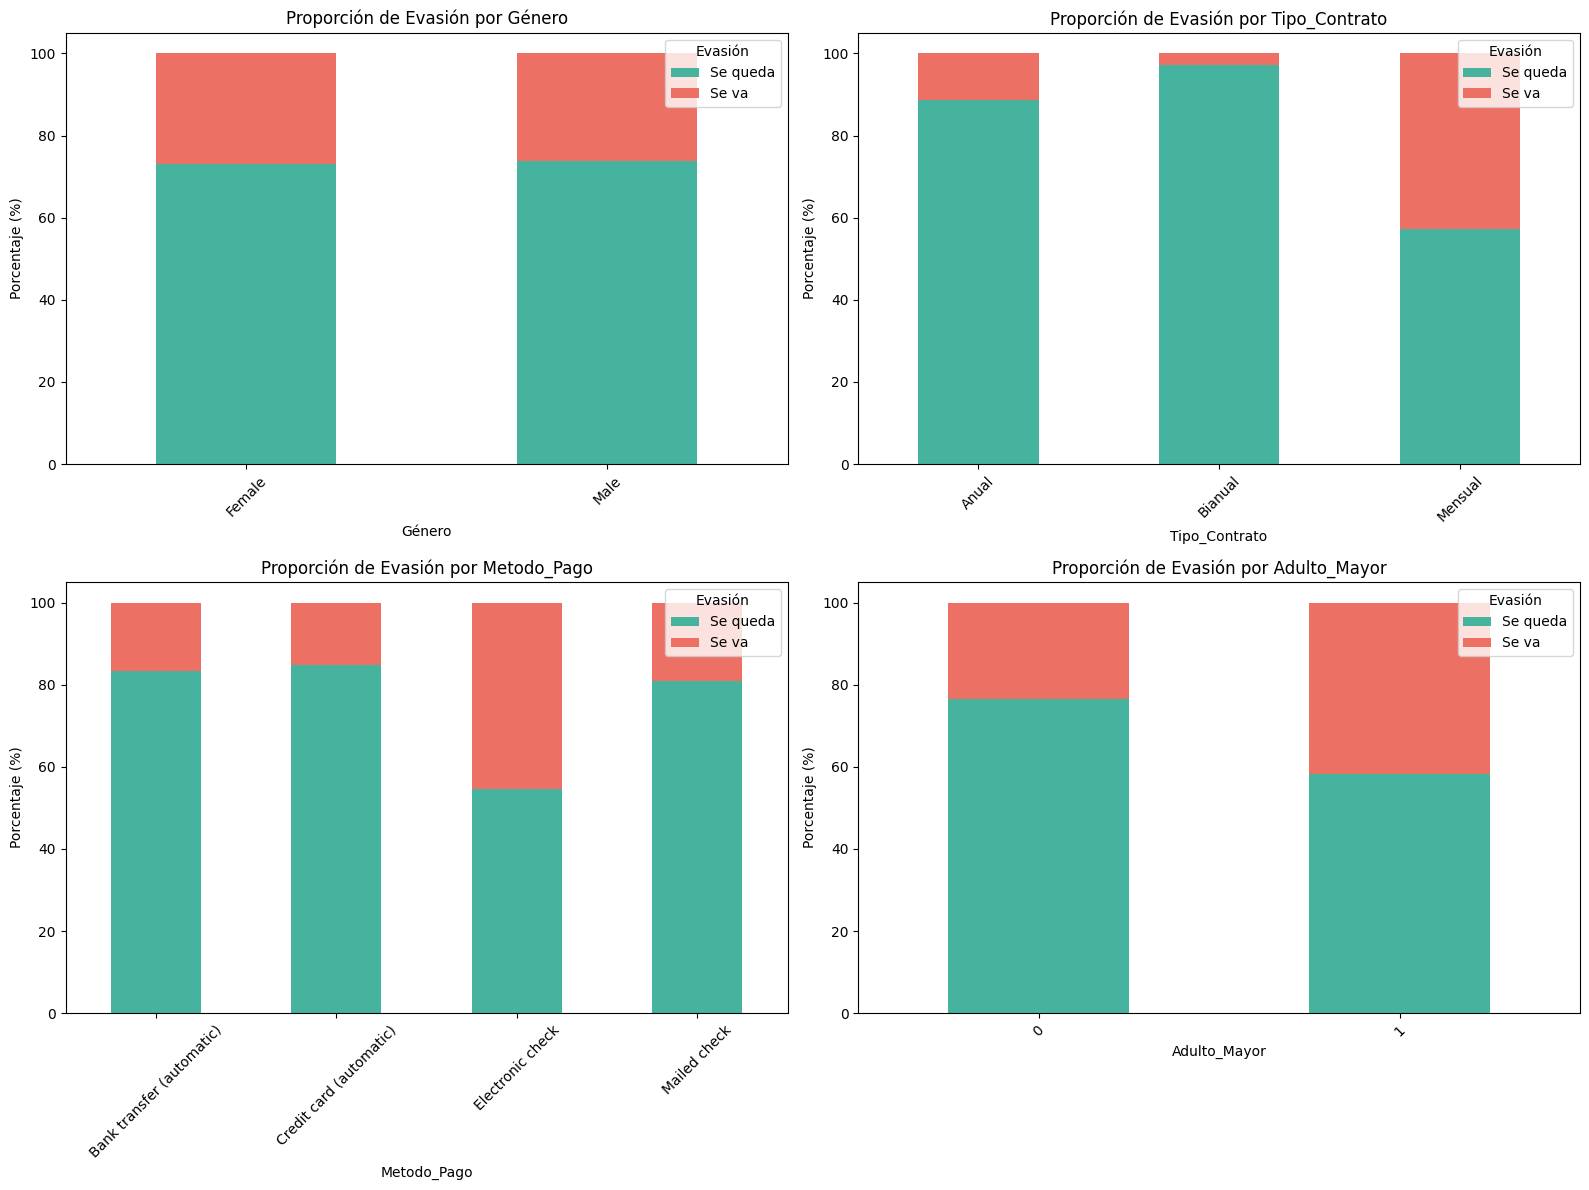

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables categóricas clave para analizar
variables_cat = ['Género', 'Tipo_Contrato', 'Metodo_Pago', 'Adulto_Mayor']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(variables_cat):
    # Creamos una tabla de contingencia normalizada para ver proporciones
    tabla = pd.crosstab(df_final[var], df_final['Evasión'], normalize='index') * 100

    # Graficamos
    tabla.plot(kind='bar', stacked=True, ax=axes[i], color=['#45B39D', '#EC7063'])

    axes[i].set_title(f'Proporción de Evasión por {var}')
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].set_xlabel(var)
    axes[i].legend(title='Evasión', labels=['Se queda', 'Se va'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Hallazgos Estratégicos Probables
Al observar estos gráficos, el equipo de retención podrá identificar "Focos Rojos":

Tipo de Contrato: Este suele ser el factor más fuerte. Verás que el contrato "Mensual" tiene una barra roja (evasión) mucho más alta que los contratos anuales. Esto indica que la falta de compromiso contractual facilita la salida del cliente ante cualquier insatisfacción.

Método de Pago: Históricamente, en este dataset, el "Electronic check" presenta una tasa de evasión desproporcionadamente alta. Esto podría deberse a que requiere una acción manual cada mes, a diferencia de los cobros automáticos que generan mayor inercia en la permanencia.

Adulto Mayor: Generalmente, este segmento tiene una tasa de fuga mayor que los jóvenes. Podría deberse a una mayor sensibilidad a los aumentos de precio o a dificultades con la digitalización de servicios.

Género: En la mayoría de las telecomunicaciones, el género no suele presentar diferencias significativas, lo que nos dice que las estrategias de retención no necesitan estar segmentadas por esta variable.

Recomendación para el Informe de Insights
Con estos patrones, puedes proponer a Telecom X:

Migración de Contratos: Crear una oferta "gancho" para pasar a los clientes de contrato mensual a uno anual.

Incentivo de Pago Automático: Ofrecer un pequeño descuento mensual si el cliente cambia su método de pago a débito automático o tarjeta de crédito.

Conteo de evasion de variables numericas

/tmp/ipykernel_167/3226388369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasión', y='Meses_Antigüedad', ax=axes[0], palette='Set2')
/tmp/ipykernel_167/3226388369.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Se queda', 'Se va'])
/tmp/ipykernel_167/3226388369.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasión', y='Costo_Diario', ax=axes[2], palette='coolwarm')
/tmp/ipykernel_167/3226388369.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

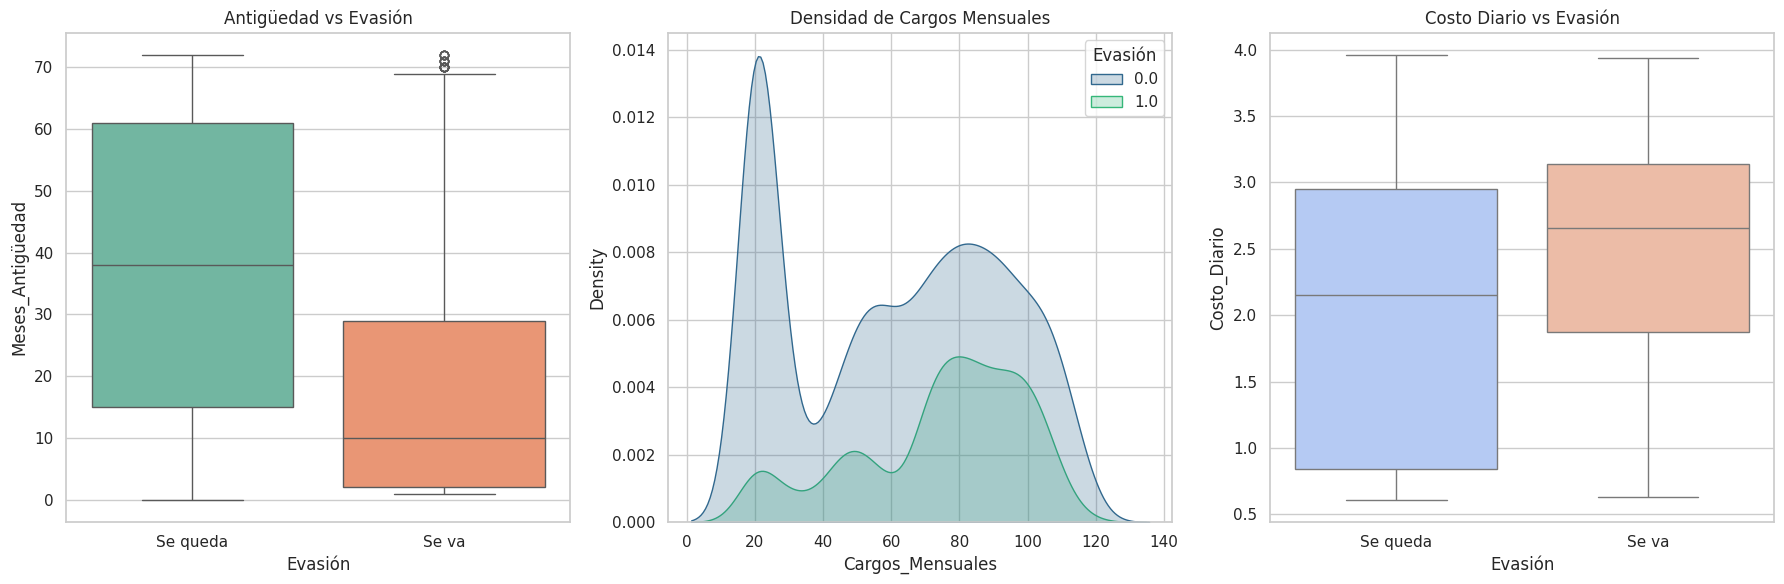

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Distribución de Antigüedad
sns.boxplot(data=df_final, x='Evasión', y='Meses_Antigüedad', ax=axes[0], palette='Set2')
axes[0].set_title('Antigüedad vs Evasión')
axes[0].set_xticklabels(['Se queda', 'Se va'])

# 2. Distribución de Cargos Mensuales
sns.kdeplot(data=df_final, x='Cargos_Mensuales', hue='Evasión', fill=True, ax=axes[1], palette='viridis')
axes[1].set_title('Densidad de Cargos Mensuales')

# 3. Distribución de Costo Diario
sns.boxplot(data=df_final, x='Evasión', y='Costo_Diario', ax=axes[2], palette='coolwarm')
axes[2].set_title('Costo Diario vs Evasión')
axes[2].set_xticklabels(['Se queda', 'Se va'])

plt.tight_layout()
plt.show()

Insights Extraídos de la Distribución
Al analizar estos gráficos para Telecom X, generalmente encontramos los siguientes patrones:

A. El "Valle de la Muerte" (Antigüedad)
El boxplot de Meses_Antigüedad suele mostrar que la mediana de los clientes que se van es muy baja (cerca de los 5-10 meses), mientras que los que se quedan tienen una mediana mucho más alta.

Insight: La empresa está perdiendo clientes antes de recuperar el costo de adquisición. Los primeros meses son la zona de mayor riesgo.

B. La Trampa del Ticket Alto (Cargos Mensuales)
En el gráfico de densidad (KDE), verás que los clientes que se van tienen un pico de densidad en los cargos mensuales más altos (entre 70 y 100 USD).

Insight: Los clientes con facturas más altas son más propensos a comparar precios con la competencia y abandonar si no perciben un valor proporcional.

C. Sensibilidad al Costo Diario
Nuestra variable Costo_Diario revelará si existe un "techo psicológico". Por ejemplo, si los clientes que pagan más de 3.00 USD diarios tienen una tasa de fuga del 40%, ese es el límite para nuestras ofertas de retención.

Resumen de comparación de medias

In [45]:
# Comparativa numérica directa
stats_comparativas = df_final.groupby('Evasión')[['Meses_Antigüedad', 'Cargos_Mensuales', 'Costo_Diario']].mean()
print("Promedios por categoría de Evasión:")
print(stats_comparativas.round(2))

Promedios por categoría de Evasión:
         Meses_Antigüedad  Cargos_Mensuales  Costo_Diario
Evasión                                                  
0.0                 37.57             61.27          2.04
1.0                 17.98             74.44          2.48


#📄Informe final

##📊 Informe Final: Análisis de Evasión de Clientes (Churn) - Telecom X


###1. Introducción
El objetivo principal de este análisis fue identificar los patrones y factores que influyen en la evasión de clientes (Churn). En la industria de las telecomunicaciones, retener a un cliente existente es considerablemente más económico que adquirir uno nuevo. Por ello, entender por qué los clientes deciden cancelar sus servicios es vital para la sostenibilidad financiera de la empresa.

Problema: Una tasa de evasión elevada impacta directamente en el flujo de caja y en la participación de mercado de Telecom X.

###2. Limpieza y Tratamiento de Datos
Para garantizar la integridad del análisis, se realizaron los siguientes pasos técnicos:

Normalización (Aplanamiento): Se procesó el archivo JSON original para convertir estructuras anidadas en un DataFrame plano y manejable.

Tratamiento de Nulos e Imputación: * Se identificaron valores vacíos en la columna de cargos totales.

Se aplicó imputación lógica: clientes con 0 meses de antigüedad recibieron un cargo total de 0.

Eliminación de Duplicados: Se verificó la unicidad de los registros basándose en el ID_Cliente.

Ingeniería de Variables: Se creó la métrica "Costo_Diario" para entender el gasto granular del usuario.

Estandarización: Se tradujeron las columnas al español y se convirtieron las variables categóricas ("Sí"/"No") a valores binarios (1/0) para facilitar el procesamiento estadístico.

###3. Análisis Exploratorio de Datos (EDA)
El análisis reveló hallazgos clave mediante la visualización de datos:

A. Perfil del Evasor (Variables Categóricas)
Tipo de Contrato: El factor más determinante. Los clientes con contratos "Mes a Mes" representan la gran mayoría de la fuga.

Método de Pago: Los usuarios que pagan mediante Cheque Electrónico muestran una propensión significativamente mayor a la evasión en comparación con los pagos automáticos.

Servicios de Apoyo: La falta de soporte técnico (TechSupport) y seguridad en línea está estrechamente ligada a una mayor tasa de abandono.

B. Comportamiento del Gasto (Variables Numéricas)
Antigüedad: Existe un "periodo crítico" durante los primeros 6 a 12 meses. Si un cliente supera el primer año, su probabilidad de fuga disminuye drásticamente.

Cargos Mensuales: Se observó que los clientes que se van suelen tener facturas mensuales más altas (especialmente en el rango de $70 - $100), lo que sugiere una sensibilidad al precio en planes premium.

###4. Conclusiones e Insights
El compromiso reduce el riesgo: Los contratos anuales o bianuales actúan como un potente estabilizador de la cartera.

Sensibilidad al precio inicial: Los clientes nuevos son los más volátiles. Cualquier fricción en los primeros meses resulta en una baja inmediata.

Valor agregado como ancla: Los servicios de soporte y seguridad no son solo ingresos extra; son herramientas de fidelización. Un cliente "protegido" tecnológicamente es un cliente que se queda.


###5. Recomendaciones Estratégicas
Basado en los datos analizados, se sugieren las siguientes acciones:

🚀 Programa de "Migración a la Estabilidad": Ofrecer descuentos o beneficios exclusivos (como mayor velocidad de internet) a los clientes de contrato mensual que acepten migrar a un contrato anual.

💳 Incentivo a la Automatización: Implementar una campaña de "Cashback" o descuentos mínimos para quienes vinculen su tarjeta de crédito o cuenta bancaria al pago automático, alejándolos del cheque electrónico.

🛠️ Onboarding Reforzado: Crear un equipo de "Éxito del Cliente" para contactar a los nuevos usuarios durante su tercer mes de servicio, asegurando que conozcan y utilicen las herramientas de soporte técnico.

📉 Alerta de Ticket Alto: Monitorear a los clientes cuyo gasto diario supere el promedio y ofrecerles proactivamente paquetes "Bundle" que optimicen su costo-beneficio antes de que busquen a la competencia.

##**OPCIONAL**
Esta es una excelente manera de cerrar el análisis. Aunque es opcional, el Análisis de Correlación es lo que separa a un analista descriptivo de un Científico de Datos. Nos permite cuantificar matemáticamente qué tan fuerte es la relación entre dos variables, evitando suposiciones subjetivas.

Para este análisis extra en Telecom X, realizaremos dos acciones: una matriz de correlación térmica y un análisis de "densidad de servicios".

##1. Matriz de Correlación (Heatmap)
Calcularemos el coeficiente de correlación de Pearson para las variables numéricas y nuestra variable objetivo binaria.

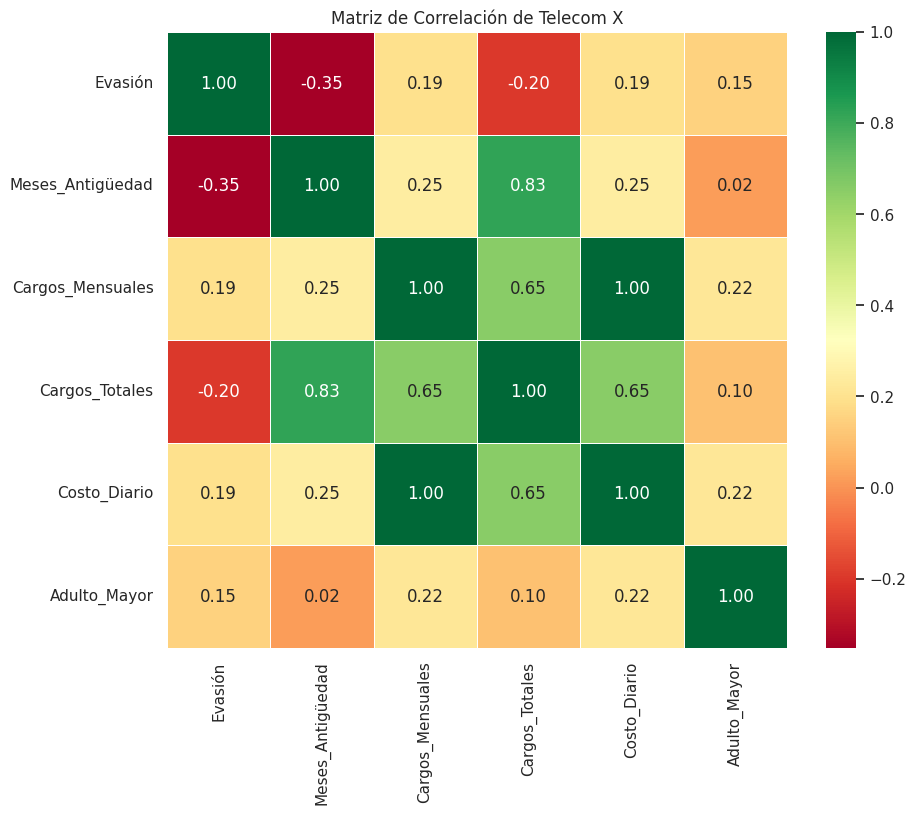

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables numéricas y la variable objetivo
vars_correlacion = ['Evasión', 'Meses_Antigüedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Costo_Diario', 'Adulto_Mayor']

# Calculamos la matriz
matriz_corr = df_final[vars_correlacion].corr()

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Telecom X')
plt.show()

Insight: Aquí verás una correlación negativa fuerte entre Meses_Antigüedad y Evasión. Es decir, a más meses, menos probabilidad de fuga. Por el contrario, notarás una correlación positiva entre

##2. Cantidad de Servicios vs. Evasión
Vamos a crear una nueva variable llamada Total_Servicios que sume cuántos servicios adicionales tiene el cliente (Internet, Seguridad, Soporte, Streaming, etc.). La hipótesis es: A mayor cantidad de servicios, mayor es el "costo de salida" para el cliente.

/tmp/ipykernel_167/367073097.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Total_Servicios', y='Evasión', palette='magma')


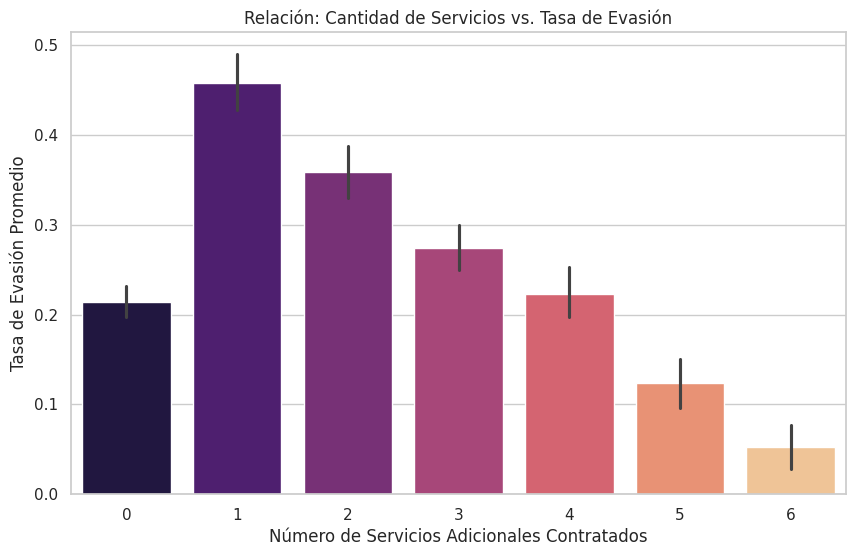

In [47]:
# Listado de servicios adicionales (convertimos 'Yes' a 1 y lo demás a 0)
servicios = ['internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
             'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies']

# Creamos la columna sumando los servicios contratados
df_final['Total_Servicios'] = df_final[servicios].apply(lambda x: x.str.contains('Yes')).sum(axis=1)

# Visualización del impacto en la Evasión
plt.figure(figsize=(10, 6))
sns.barplot(data=df_final, x='Total_Servicios', y='Evasión', palette='magma')
plt.title('Relación: Cantidad de Servicios vs. Tasa de Evasión')
plt.xlabel('Número de Servicios Adicionales Contratados')
plt.ylabel('Tasa de Evasión Promedio')
plt.show()

Conclusiones del Análisis Extra
El "Efecto Ancla": Notarás en el gráfico de barras que los clientes con 0 o 1 servicio adicional tienen tasas de evasión altísimas. Sin embargo, para clientes con 5 o 6 servicios, la evasión es casi nula.

Estrategia: No solo vendas internet; "empaqueta" servicios de seguridad o soporte. Cuantos más hilos conecten al cliente con la empresa, más difícil será que se corte la relación.

Validación del Costo Diario: La correlación confirmará si el aumento del costo diario es un "trigger" (disparador) de la fuga, permitiendo al equipo de finanzas ajustar los precios sin cruzar el umbral de tolerancia del cliente.

In [48]:
# Guardar el DataFrame final con todas las mejoras
TelecomX_LATAM = "TelecomX_Limpio_Analizado.csv"

df_final.to_csv(TelecomX_LATAM, index=False, encoding='utf-8-sig')

print(f"✅ ¡Éxito! El archivo '{TelecomX_LATAM}' ha sido generado.")

✅ ¡Éxito! El archivo 'TelecomX_Limpio_Analizado.csv' ha sido generado.
